# Configuration

In [1]:
import os 
import pickle 

if True ^ os.getcwd().endswith('hte-and-targeting"'):
    os.chdir('..')

from typing import Iterable

In [2]:
import random
import pandas as pd 
import numpy as np

from tqdm import tqdm

In [3]:
# visualization
import matplotlib.pyplot as plt
import seaborn as sns

# visualization params
# label size
tick_label_size = 12
legend_label_size = 12
axis_label_size = 14
title_size = 18
# font
plt.rcParams['font.family'] = 'serif'

# model label map 
model_label_map = {
    'plugin': 'Plugin', 
    'standard_bootstrap': 'Standard Bootstrap', 
    'mn_bootstrap': 'm-out-of-n Bootstrap', 
    'num_bootstrap': 'Numerical Bootstrap'
}

In [4]:
from core.variables import *
from core.dgp import MultipleSegmentsTreatmentSelection as MultipleSegments
import core.treatment_selection_multiple_segments as tsms

# DGP

In [5]:
dgp_params = {
    'te_arr': np.array([[0.1, 0.2], [0.2, 0.1], [0.2, 0.3]]), 
    'response_type': 'continuous', 'noise_std': 1,
}

dgp = MultipleSegments(**dgp_params)
segment_arr, treatment_arr, outcome_arr = dgp.sample(500, seed=0)
targ_customers = dgp.sample_individuals(100, seed=0)

# Demand Model

In [6]:
emp_te_arr = tsms.estimate_te(segment_arr, treatment_arr, outcome_arr, dgp.n_segments, dgp.n_treatments)

for segment_idx in range(dgp.n_segments):
    for treatment_idx in range(dgp.n_treatments):
        print(f'Segment {segment_idx}, Treatment {treatment_idx}: True TE = {dgp.te_arr[segment_idx, treatment_idx]:.4f}, Estimated TE = {emp_te_arr[segment_idx, treatment_idx]:.4f}')


Segment 0, Treatment 0: True TE = 0.1000, Estimated TE = -0.0099
Segment 0, Treatment 1: True TE = 0.2000, Estimated TE = 0.1133
Segment 1, Treatment 0: True TE = 0.2000, Estimated TE = 0.1168
Segment 1, Treatment 1: True TE = 0.1000, Estimated TE = 0.1808
Segment 2, Treatment 0: True TE = 0.2000, Estimated TE = 0.1774
Segment 2, Treatment 1: True TE = 0.3000, Estimated TE = 0.4204


# Optimization

In [7]:
plugin_decision, plugin_val_est = tsms.optimize(emp_te_arr, targ_customers, budgets=[None, 10])
true_plugin_val = tsms.obj_func(targ_customers, dgp.te_arr, plugin_decision)

print(f'Plugin Decision: {plugin_decision}')
print(f'Estimated Targeting Value: {plugin_val_est:.2f}')
print(f'True Targeting Value: {true_plugin_val:.2f}')

print()
print(f"Winner's curse (measured in MPE): {100 * (plugin_val_est - true_plugin_val)/true_plugin_val:.2f}%")

Plugin Decision: [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 0 0 0 0 0 1 1 1 0 1 0 0 0 1 0 0 0 0
 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1]
Estimated Targeting Value: 10.80
True Targeting Value: 17.10

Winner's curse (measured in MPE): -36.82%


# Winner's Curse

In [43]:
operations_params = {'budgets': [None, 30]}

# dgp params
dgp_params = {
    'te_arr': np.array([[0.1, 0.15], [0.15, 0.10], [0.12, 0.17]]), 
    'response_type': 'continuous', 'noise_std': 1,
}

# data params
data_params = {'sample_size': 100, 'n_customers': 100}

# experiment params
experiment_params = {'n_experiments': 5000, 'stats': 'mean'}

# estimators
estimators_dict = {} 

result_records = tsms.repeated_experiments(
    operations_params=operations_params, 
    dgp_params=dgp_params, 
    data_params=data_params, 
    experiment_params=experiment_params, 
    estimators_dict=estimators_dict, 
    verbose=False, 
    n_jobs=-1
)

wc_measures_dict = tsms.calculate_winners_curse_measures(
    result_records, estimators_dict, data_params
)

print(f"Average Estimated Targeting Value: {wc_measures_dict['nc_val_est_avg']:.4f} ({wc_measures_dict['nc_val_est_se']:.4f})")
print(f"Average True Targeting Value: {wc_measures_dict['nc_val_true_avg']:.4f} ({wc_measures_dict['nc_val_true_se']:.4f})")
print(f"Average Winner's Curse: {wc_measures_dict['nc_wc_avg']:.4f} ({wc_measures_dict['nc_wc_se']:.4f})")
print(f"Average Winner's Curse Percentage of True Value: {100 * wc_measures_dict['nc_wc_pct_avg']:.2f}% ({100 * wc_measures_dict['nc_wc_pct_se']:.2f}%)")

print(f"\nRMSE={wc_measures_dict['nc_wc_rmse']:.4f}")

Average Estimated Targeting Value: 21.2818 (1.2880)
Average True Targeting Value: 12.9868 (0.1227)
Average Winner's Curse: 8.2950 (1.2904)
Average Winner's Curse Percentage of True Value: 65.14% (10.14%)

RMSE=15.3404


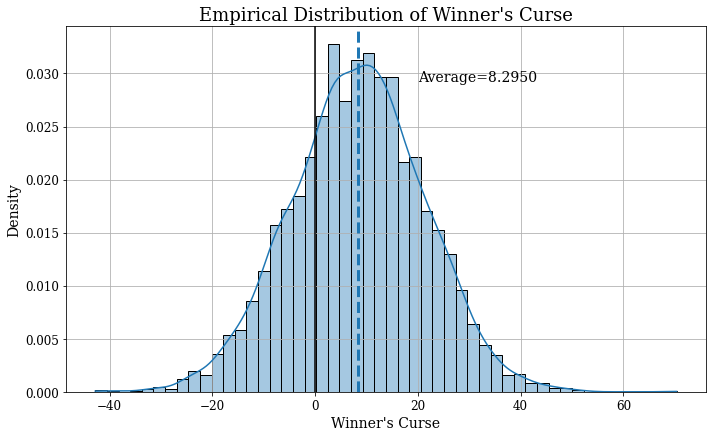

In [44]:
fig, ax = plt.subplots(1, 1, figsize=(10, 6.18))

sns.histplot(wc_measures_dict['nc_wc_arr'], bins=50, kde=True, stat='density', ax=ax, color='C0', alpha=0.4)
ax.axvline(wc_measures_dict['nc_wc_avg'], color='C0', linestyle='--', linewidth=3)
ax.axvline(0, color='black', linestyle='-', linewidth=1.5)
ax.annotate(
    f"Average={wc_measures_dict['nc_wc_avg']:.4f}", 
    xy=(0.55, 0.85), xycoords='axes fraction', fontsize=axis_label_size
)
ax.set_title("Empirical Distribution of Winner's Curse", fontsize=title_size)

ax.tick_params(axis='both', which='major', labelsize=tick_label_size)
ax.set_xlabel("Winner's Curse", fontsize=axis_label_size)
ax.set_ylabel('Density', fontsize=axis_label_size)
ax.grid()

plt.tight_layout()
plt.show()

# Estimating Winner's Curse

In [10]:
dgp = MultipleSegments(**dgp_params) 
segment_arr, treatment_arr, outcome_arr = dgp.sample(data_params['sample_size'], seed=0)
targ_customers = dgp.sample_individuals(data_params['n_customers'], seed=0)

## Standard Bootstrap

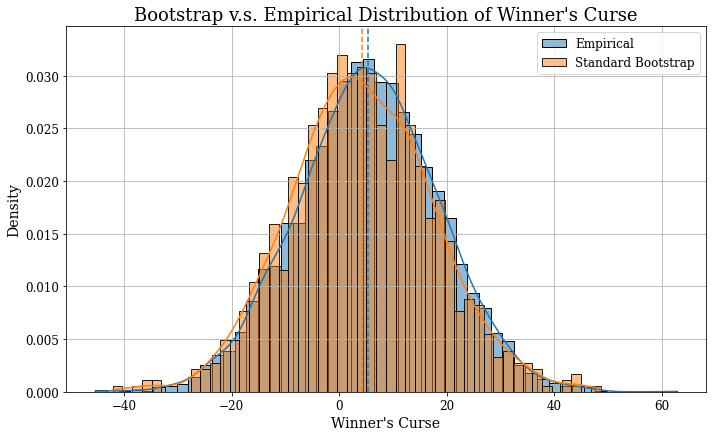

In [11]:
# generate bootstrap distribution
boot_wc_dstn_arr = tsms.get_wc_boot_dstn(
    segments=segment_arr, treatments=treatment_arr, outcomes=outcome_arr,
    targ_customers=targ_customers, 
    n_segments=dgp.n_segments, n_treatments=dgp.n_treatments,
    **operations_params, n_bootstraps=1000, n_jobs=-1, verbose=False, 
)

fig, ax = plt.subplots(1, 1, figsize=(10, 6.18))

sns.histplot(wc_measures_dict['nc_wc_arr'], bins=50, kde=True, stat='density', ax=ax, color='C0', label='Empirical')
ax.axvline(wc_measures_dict['nc_wc_avg'], color='C0', linestyle='--')

sns.histplot(boot_wc_dstn_arr, bins=50, kde=True, stat='density', ax=ax, color='C1', label='Standard Bootstrap')
ax.axvline(boot_wc_dstn_arr.mean(), color='C1', linestyle='--')

ax.set_title("Bootstrap v.s. Empirical Distribution of Winner's Curse", fontsize=title_size)
ax.set_xlabel("Winner's Curse", fontsize=axis_label_size)
ax.set_ylabel('Density', fontsize=axis_label_size)
ax.legend(fontsize=legend_label_size)
ax.tick_params(axis='both', which='major', labelsize=tick_label_size)
ax.grid()

plt.tight_layout()
plt.show()

## m-out-of-n Bootstrap


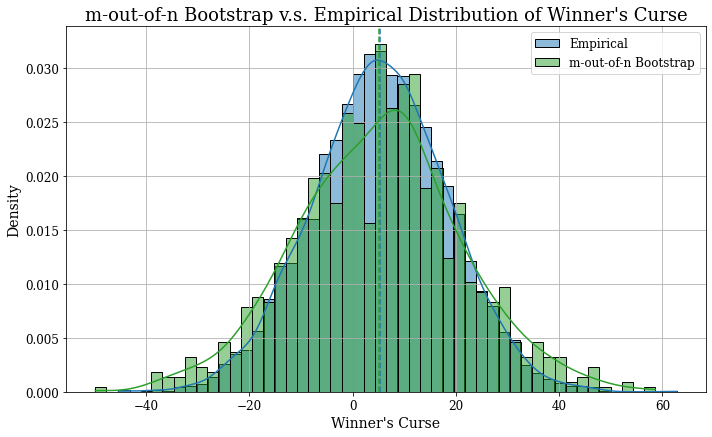

In [13]:
# generate bootstrap distribution
boot_wc_dstn_arr = tsms.get_wc_m_out_of_n_boot_dstn(
    segments=segment_arr, treatments=treatment_arr, outcomes=outcome_arr,
    targ_customers=targ_customers,
    n_segments=dgp.n_segments, n_treatments=dgp.n_treatments,
    **operations_params, power=0.9, n_bootstraps=1000, n_jobs=-1, verbose=False, 
)

fig, ax = plt.subplots(1, 1, figsize=(10, 6.18))

sns.histplot(wc_measures_dict['nc_wc_arr'], bins=50, kde=True, stat='density', ax=ax, color='C0', label='Empirical')
ax.axvline(wc_measures_dict['nc_wc_avg'], color='C0', linestyle='--')

sns.histplot(boot_wc_dstn_arr, bins=50, kde=True, stat='density', ax=ax, color='C2', label='m-out-of-n Bootstrap')
ax.axvline(boot_wc_dstn_arr.mean(), color='C2', linestyle='--')

ax.set_title("m-out-of-n Bootstrap v.s. Empirical Distribution of Winner's Curse", fontsize=title_size)
ax.set_xlabel("Winner's Curse", fontsize=axis_label_size)
ax.set_ylabel('Density', fontsize=axis_label_size)
ax.legend(fontsize=legend_label_size)
ax.tick_params(axis='both', which='major', labelsize=tick_label_size)
ax.grid()

plt.tight_layout()
plt.show()

## Numerical Bootstrap


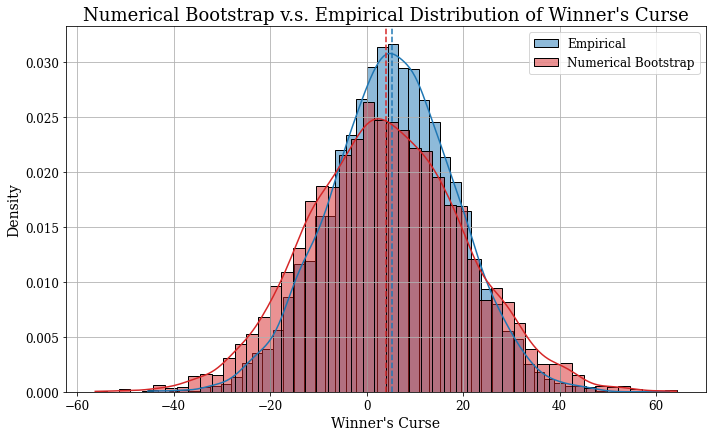

In [15]:
# generate bootstrap distribution
boot_wc_dstn_arr = tsms.get_wc_num_boot_dstn(
    segments=segment_arr, treatments=treatment_arr, outcomes=outcome_arr,
    targ_customers=targ_customers,
    n_segments=dgp.n_segments, n_treatments=dgp.n_treatments,
    **operations_params, power=-0.45, n_bootstraps=5000, n_jobs=-1, verbose=False, 
)

fig, ax = plt.subplots(1, 1, figsize=(10, 6.18))

sns.histplot(wc_measures_dict['nc_wc_arr'], bins=50, kde=True, stat='density', ax=ax, color='C0', label='Empirical')
ax.axvline(wc_measures_dict['nc_wc_avg'], color='C0', linestyle='--')

sns.histplot(boot_wc_dstn_arr, bins=50, kde=True, stat='density', ax=ax, color='C3', label='Numerical Bootstrap')
ax.axvline(boot_wc_dstn_arr.mean(), color='C3', linestyle='--')

ax.set_title("Numerical Bootstrap v.s. Empirical Distribution of Winner's Curse", fontsize=title_size)
ax.set_xlabel("Winner's Curse", fontsize=axis_label_size)
ax.set_ylabel('Density', fontsize=axis_label_size)
ax.legend(fontsize=legend_label_size)
ax.tick_params(axis='both', which='major', labelsize=tick_label_size)
ax.grid()

plt.tight_layout()
plt.show()

# Bias Correction

In [56]:
operations_params = {'budgets': [None, 30]}

# dgp params
dgp_params = {
    'te_arr': np.array([[0.1, 0.15], [0.15, 0.10], [0.12, 0.17]]), 
    'response_type': 'continuous', 'noise_std': 1,
}

# data params
data_params = {'sample_size': 100, 'n_customers': 100}

# experiment params
experiment_params = {'n_experiments': 1000, 'stats': 'mean'}

# estimators
estimators_dict = {
    'standard_bootstrap': {
        'estimator': tsms.bootstrap_correction_estimate, 
        'params': {
            'n_bootstraps': 500, 'bootstrap_method': 'standard',
            'n_jobs': 1,
        }, 
        'display_name': 'Standard Bootstrap'
    }, 
    'mn_bootstrap': {
        'estimator': tsms.bootstrap_correction_estimate, 
        'params': {
            'n_bootstraps': 500, 'bootstrap_method': 'm_out_of_n', 
            'power': 0.95, 'n_jobs': 1,
        }, 
        'display_name': 'm-out-of-n Bootstrap'
    }, 
    'num_bootstrap': {
        'estimator': tsms.bootstrap_correction_estimate, 
        'params': {
            'n_bootstraps': 500, 'bootstrap_method': 'numerical', 
            'power': - 0.45, 'n_jobs': 1,
        }, 
        'display_name': 'Numerical Bootstrap'
    }
}

In [57]:
result_records = tsms.repeated_experiments(
    operations_params=operations_params, 
    dgp_params=dgp_params, 
    data_params=data_params, 
    experiment_params=experiment_params, 
    estimators_dict=estimators_dict, 
    verbose=True, n_jobs=-1
)

wc_measures_dict = tsms.calculate_winners_curse_measures(
    result_records=result_records,
    estimators_dict=estimators_dict, data_params=data_params
)

Running 1000 experiments...


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 10 concurrent workers.
[Parallel(n_jobs=-1)]: Done  30 tasks      | elapsed:    1.5s
[Parallel(n_jobs=-1)]: Done 180 tasks      | elapsed:    7.7s
[Parallel(n_jobs=-1)]: Done 430 tasks      | elapsed:   17.6s
[Parallel(n_jobs=-1)]: Done 780 tasks      | elapsed:   31.8s
[Parallel(n_jobs=-1)]: Done 1000 out of 1000 | elapsed:   40.8s finished


In [58]:
wc_dict = {}
for estimator in ['nc'] + list(estimators_dict.keys()):
    display_name = estimators_dict[estimator]['display_name'] if estimator != 'nc' else 'No Correction'

    wc_dict.update({
        display_name: {
            "Avg. Winner's Curse": wc_measures_dict[f'{estimator}_wc_avg'], "S.E. Winner's Curse": wc_measures_dict[f'{estimator}_wc_se'],
            # 'wc_pct_avg ': wc_measures_dict[f'{estimator}_wc_pct_avg'], 'wc_pct_se': wc_measures_dict[f'{estimator}_wc_pct_se'],
            # 'wc_rmse': wc_measures_dict[f'{estimator}_wc_rmse']
        }
    })

wc_df = pd.DataFrame.from_dict(wc_dict, orient='index')
del wc_dict 

print("Overestimated Profit: ")
wc_df.round(4)

Overestimated Profit: 


,Avg. Winner's Curse,S.E. Winner's Curse
No Correction,8.4351,1.2860
Standard Bootstrap,2.9924,1.3304
m-out-of-n Bootstrap,1.9392,1.3307
Numerical Bootstrap,1.5647,1.3453


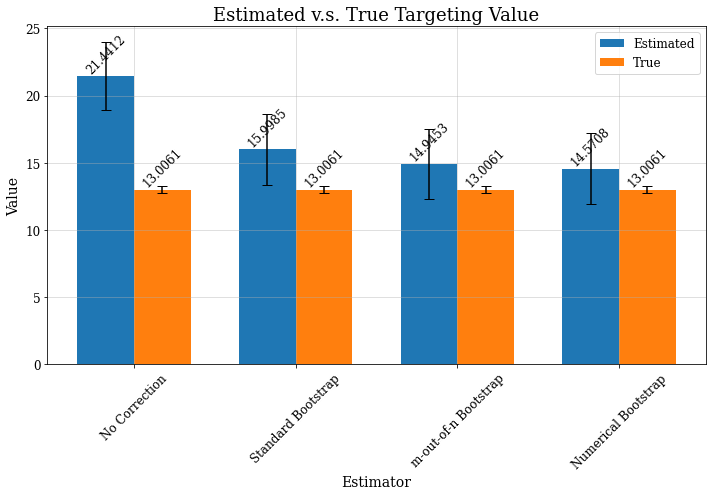

In [59]:
fig, ax = plt.subplots(1, 1, figsize=(10, 7))

x = np.arange(len(estimators_dict) + 1)
width = 0.35

ax.bar(
    x - width/2, 
    height=[wc_measures_dict[f'{estimator}_val_est_avg'] for estimator in ['nc'] + list(estimators_dict.keys())],
    yerr=[1.96 * wc_measures_dict[f'{estimator}_val_est_se'] for estimator in ['nc'] + list(estimators_dict.keys())],
    capsize=5, 
    width=width, label='Estimated', color='C0'
)

ax.bar(
    x + width/2, 
    height=[wc_measures_dict[f'{estimator}_val_true_avg'] for estimator in ['nc'] + list(estimators_dict.keys())],
    yerr=[1.96 * wc_measures_dict[f'{estimator}_val_true_se'] for estimator in ['nc'] + list(estimators_dict.keys())],
    capsize=5, 
    width=width, label='True', color='C1'
)

# add text annotation
for i, (val_est, val_true) in enumerate(zip(
    [wc_measures_dict[f'{estimator}_val_est_avg'] for estimator in ['nc'] + list(estimators_dict.keys())],
    [wc_measures_dict[f'{estimator}_val_true_avg'] for estimator in ['nc'] + list(estimators_dict.keys())]
)):
    ax.text(
        i - width/2, val_est, f"{val_est:.4f}", 
        ha='center', va='bottom', fontsize=tick_label_size, rotation=45
    )
    ax.text(
        i + width/2, val_true, f"{val_true:.4f}", 
        ha='center', va='bottom', fontsize=tick_label_size, rotation=45
    )

ax.set_title("Estimated v.s. True Targeting Value", fontsize=title_size)
ax.set_xlabel("Estimator", fontsize=axis_label_size)
ax.set_ylabel("Value", fontsize=axis_label_size)
ax.set_xticks(x)
ax.set_xticklabels(['No Correction'] + [estimator['display_name'] for estimator in estimators_dict.values()], rotation=45)
ax.tick_params(axis='both', which='major', labelsize=tick_label_size)

ax.legend(['Estimated', 'True'], fontsize=legend_label_size)
ax.grid(alpha=0.5)

plt.tight_layout()
plt.show()

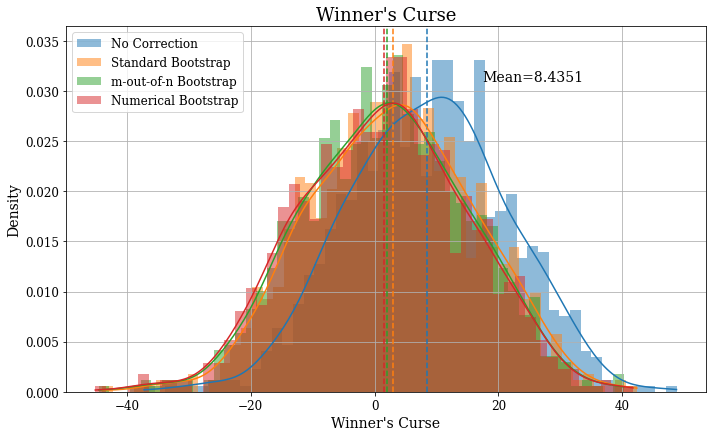

In [60]:
fig, ax = plt.subplots(1, 1, figsize=(10, 6.18))

# winner's curse MPE
for idx, estimator in enumerate(['nc', 'standard_bootstrap', 'mn_bootstrap', 'num_bootstrap']):
    display_name = estimators_dict[estimator]['display_name'] if estimator != 'nc' else 'No Correction'
    sns.histplot(
        wc_measures_dict[f'{estimator}_wc_arr'], bins=50, kde=True, stat='density', ax=ax, color=f'C{idx}', edgecolor=None, 
        label=display_name
    )
    ax.axvline(wc_measures_dict[f'{estimator}_wc_avg'], color=f'C{idx}', linestyle='--')


ax.annotate(
    f"Mean={wc_measures_dict['nc_wc_avg']:.4f}", 
    xy=(0.65, 0.85), xycoords='axes fraction', fontsize=axis_label_size
)

ax.set_title('Winner\'s Curse', fontsize=title_size)
ax.set_xlabel('Winner\'s Curse', fontsize=axis_label_size)
ax.tick_params(labelsize=tick_label_size)
ax.legend(loc='upper left', fontsize=legend_label_size)
ax.set_ylabel('Density', fontsize=axis_label_size)
ax.grid()

plt.tight_layout()
plt.show()

# Sensitivity Analysis

## Sample Size

In [53]:
operations_params = {'budgets': [None, 30]}

# dgp params
dgp_params = {
    'te_arr': np.array([[0.1, 0.15], [0.15, 0.10], [0.12, 0.17]]), 
    'response_type': 'continuous', 'noise_std': 1,
}

# data params
data_params = {'sample_size': 100, 'n_customers': 100}

# experiment params
experiment_params = {'n_experiments': 1000, 'stats': 'mean'}

# estimators
estimators_dict = {
    'standard_bootstrap': {
        'estimator': tsms.bootstrap_correction_estimate, 
        'params': {
            'n_bootstraps': 500, 'bootstrap_method': 'standard',
            'n_jobs': 1,
        }, 
        'display_name': 'Standard Bootstrap'
    }, 
    'mn_bootstrap': {
        'estimator': tsms.bootstrap_correction_estimate, 
        'params': {
            'n_bootstraps': 500, 'bootstrap_method': 'm_out_of_n', 
            'power': 0.95, 'n_jobs': 1,
        }, 
        'display_name': 'm-out-of-n Bootstrap'
    }, 
    'num_bootstrap': {
        'estimator': tsms.bootstrap_correction_estimate, 
        'params': {
            'n_bootstraps': 500, 'bootstrap_method': 'numerical', 
            'power': - 0.45, 'n_jobs': 1,
        }, 
        'display_name': 'Numerical Bootstrap'
    }
}

In [54]:
sample_sizes = np.array([100, 200, 300, 400, 500, 600, 700, 1000])

result_dict = {sample_size: None for sample_size in sample_sizes}

for sample_size in tqdm(sample_sizes):
    data_params['sample_size'] = int(sample_size)
    result_dict[sample_size] = tsms.repeated_experiments(
        operations_params=operations_params, 
        dgp_params=dgp_params, 
        data_params=data_params, 
        experiment_params=experiment_params, 
        estimators_dict=estimators_dict, 
        verbose=False, n_jobs=-1
    )

for key in result_dict.keys():
    result_dict[key] = tsms.calculate_winners_curse_measures(
        result_records=result_dict[key],
        estimators_dict=estimators_dict, data_params=data_params
    )

100%|██████████| 8/8 [08:01<00:00, 60.25s/it]


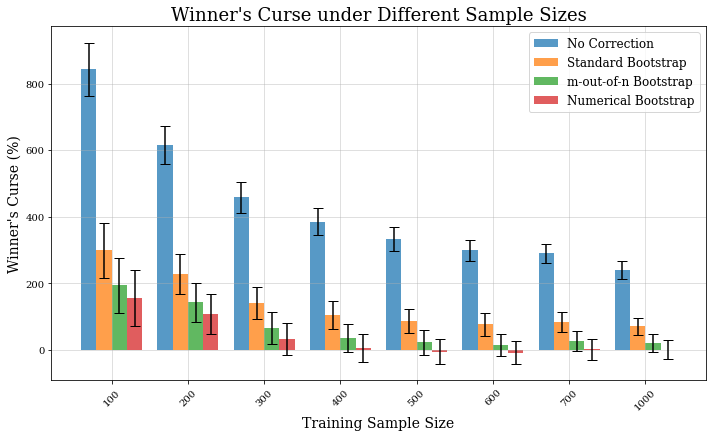

In [55]:
wc_avg_arr = np.array([result_dict[key]['nc_wc_avg'] for key in result_dict.keys()])
wc_se_arr = np.array([result_dict[key]['nc_wc_se'] for key in result_dict.keys()])

fig, ax = plt.subplots(1, 1, figsize=(10, 6.18))

width = 0.2

# plot winner's curse of no correction for each te_diff / noise_std pair
for idx, estimator in enumerate(['nc', 'standard_bootstrap', 'mn_bootstrap', 'num_bootstrap']):

    display_name = estimators_dict[estimator]['display_name'] if estimator != 'nc' else 'No Correction'
    wc_avg_arr = 100 * np.array([result_dict[key][f'{estimator}_wc_avg'] for key in result_dict.keys()])
    wc_se_arr = 100 * np.array([result_dict[key][f'{estimator}_wc_se'] for key in result_dict.keys()])
    ax.bar(
        np.arange(len(wc_avg_arr)) + (idx - 1.5) * width, wc_avg_arr, yerr=1.96 * wc_se_arr, capsize=5, color=f'C{idx}', alpha=0.75, width=width
    )

ax.set_title("Winner's Curse under Different Sample Sizes", fontsize=title_size)
ax.set_xlabel('Training Sample Size', fontsize=axis_label_size)
ax.set_ylabel("Winner's Curse (%)", fontsize=axis_label_size)
ax.set_xticks(np.arange(len(wc_avg_arr)))
ax.set_xticklabels(sample_sizes, rotation=45)
ax.grid(True, alpha=0.5)
ax.legend(['No Correction'] + [estimators_dict[estimator]['display_name'] for estimator in ['standard_bootstrap', 'mn_bootstrap', 'num_bootstrap']], fontsize=legend_label_size)

plt.tight_layout()
plt.show()